Welcome to this coding project!
This is the main document of the final project for SDS210 FS2026 - First step is to load the data and investigate it. At the beginning I was not sure which data format to choose so I looked at the .csv first to get an overview of the data (data was from the provided link "Geodata Zürich"). First also a look at the metadata.pdf file provided with the download to see which columns are present. I tend to work in the wrong directory > always check path first to get also relative paths right from beginning and check if in correct conda env (first code line below):

Overall research interest: bla bla and RQs

In [ ]:
from pathlib import Path
print(Path.cwd())

#type "conda activate sds-env" in Anaconda Prompt > conda env list (sds-env) C: > then connect pycharm interpreter so knows to use conda!!
#type git status in Terminal 
#type echo .idea/ >> .gitignore to ignore things or just add on bottom of file
#git add . -> immer nehmen
#git commit -m "update something" -> save local file
#git push -> upload to git
#conda env export > environment.yml

Read the data with pandas, as learned in L6 and look how many entries there are and how the data is structured

In [ ]:
import pandas as pd

df_reports = pd.read_csv('../data/raw/stzh_reports.csv', sep =",")
print(len(df_reports))
print(df_reports.columns)


Take a look at the first entry to see whats in data:  

In [ ]:
print(df_reports.head(1))

After looking at the data and its structure its apparent that it needs some cleaning: some attributes (columns) maybe are are not needed and some are in the wrong format. Lets print the data to visually inspect it too with geopandas: CAREFUL: we need to load the geometry and the spatial methods so we load it into a geodataframe take the columns and fuse it into shapely objects > here points

Text(86.90529139805456, 0.5, 'Nort (EPSG:2056)')

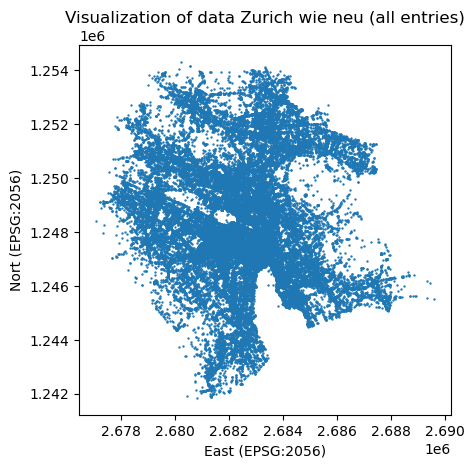

In [62]:
import geopandas as gpd

gdf_reports = gpd.GeoDataFrame(df_reports, geometry=gpd.points_from_xy(df_reports["e"], df_reports["n"]), crs="EPSG:2056")
ax = gdf_reports.plot(markersize=0.5)
ax.set_title("Visualization of data Zurich wie neu (all entries)")
ax.set_xlabel("East (EPSG:2056)")
ax.set_ylabel("Nort (EPSG:2056)")

Now lets load the Quartiere data also with pandas and have a look at it: 

In [ ]:
import pandas as pd

#df_neighborhoods = pd.read_csv('../data/raw/stzh_neighborhoods.csv', sep =",")
print(len(df_neighborhoods))
print(df_neighborhoods.columns)
print(df_neighborhoods.head(2))
print(df_neighborhoods['geometry'].head(1))
print(df_neighborhoods['geometry'].isna().sum())

 Now lets have a look at the spatial learned in L7 with shapely and well known text (WKT) >  Polygon: Created using at least three coordinate tuples to form a closed surface. A Polygon can also contain optional interior rings to represent negative space or “holes” inside the shape. Used for areas like lakes or country borders

In [51]:
with open('../data/raw/stzh_neighborhoods.csv', 'r', encoding='utf-8-sig') as f:
    lines = f.readlines()

header = lines[0].strip()
cleaned = [header] #keep the header

for line in lines[1:]:
    line = line.strip()        # remove newlines
    line = line.strip('"')     # remove outer quotes
    line = line.replace('""', '"')  # fix escaped quotes
    cleaned.append(line)

with open('../data/processed/stzh_neighborhoods_clean.csv', 'w', encoding='utf-8') as f:
    f.write('\n'.join(cleaned))

print("Done! Saved to processed folder.")

Done! Saved to processed folder.


Loading the data as is gives a type error because is NaN we need to clean the code first 

In [50]:
line = '"1,73,Hirslanden,7,Kreis 7,""POLYGON ((123 456,789 012))"" "'
line = line.strip('"')
print(line)
line = line.replace('""', '"')
print(line)

1,73,Hirslanden,7,Kreis 7,""POLYGON ((123 456,789 012))"" 
1,73,Hirslanden,7,Kreis 7,"POLYGON ((123 456,789 012))" 


In [58]:
df_neighborhoods = pd.read_csv('../data/processed/stzh_neighborhoods_clean.csv', quotechar='"')


ParserError: Error tokenizing data. C error: Expected 973 fields in line 5, saw 1500


In [60]:
import geopandas as gpd
from shapely import wkt

df_neighborhoods['geometry'] = df_neighborhoods['geometry'].apply(wkt.loads)
gdf_neighborhoods = gpd.GeoDataFrame(df_neighborhoods, geometry='geometry', crs='EPSG:2056')

ax = gdf_neighborhoods.plot()
ax.set_title("Visualization of data Neighborhoods (=Quartiere) of Zurich")
ax.set_xlabel("East (EPSG:2056)")
ax.set_ylabel("Nort (EPSG:2056)")


TypeError: Expected bytes or string, got Polygon

In [ ]:
df_neighborhoods = pd.read_csv(
    '../data/raw/stzh_neighborhoods.csv',
    header=0,
    doublequote=True,
    encoding='utf-8-sig'
)

print(df_neighborhoods.columns.tolist())
print(df_neighborhoods.head(2)[['qnr', 'qname', 'geometry']])

  qnr       qname                                           geometry
0  73  Hirslanden  POLYGON ((2684457 1246514.8, 2684466.2 1246519...
1  83     Weinegg  POLYGON ((2684457.5 1246512.8, 2684458.2 12465...
2  82   Mühlebach  POLYGON ((2684270 1246566.8, 2684271.5 1246562...


Text(77.6045500218804, 0.5, 'Nort (EPSG:2056)')

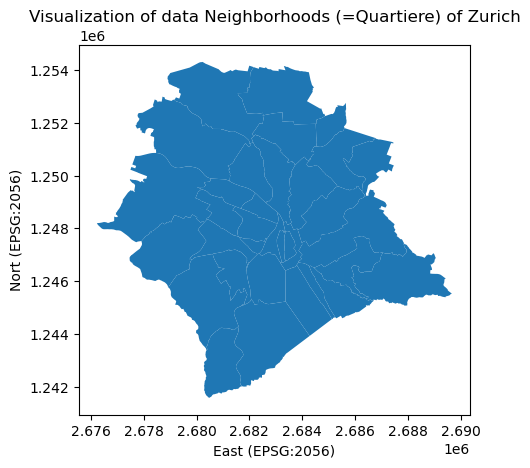

In [61]:
from shapely import wkt

with open('../data/processed/stzh_neighborhoods_clean.csv', 'r', encoding='utf-8') as f:
    lines = f.readlines()

header = lines[0].strip().split(',')  # ['objectid', 'qnr', 'qname', 'knr', 'kname', 'geometry']
rows = []

for line in lines[1:]:
    line = line.strip()
    # The geometry is the last field, everything before the 6th comma is the other columns
    parts = line.split(',', 5)   # split on first 5 commas only
    rows.append(parts)

df_neighborhoods = pd.DataFrame(rows, columns=header)
df_neighborhoods['geometry'] = df_neighborhoods['geometry'].str.strip('"').apply(wkt.loads)
gdf_neighborhoods = gpd.GeoDataFrame(df_neighborhoods, geometry='geometry', crs='EPSG:2056')

print(gdf_neighborhoods[['qnr', 'qname', 'geometry']].head(3))
ax = gdf_neighborhoods.plot()
ax.set_title("Visualization of data Neighborhoods (=Quartiere) of Zurich")
ax.set_xlabel("East (EPSG:2056)")
ax.set_ylabel("Nort (EPSG:2056)")
